<a href="https://colab.research.google.com/github/ttb-git/Awesome-Geospatial/blob/master/mo_gymnasium_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: install and import the libraries

In [1]:
!pip install mo-gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.8/481.8 kB 9.9 MB/s eta 0:00:00


In [2]:
import sys
!{sys.executable} -m pip install moviepy

In [3]:
import gymnasium as gym
import mo_gymnasium as mo_gym

## Step 2: create an environment

In [11]:
env = mo_gym.make("mo-mountaincar-v0", render_mode="rgb_array")

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


## Step 3: extract environment information

In [12]:
env.observation_space

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)

In [8]:
env.action_space

Discrete(3)

In [15]:
env.unwrapped.reward_space

Box(-1.0, [-1.  0.  0.], (3,), float32)

## Step 4: use Gymnasium features in MO-Gymnasium

In [18]:
from gymnasium.wrappers import RecordVideo

In [19]:
env = RecordVideo(env, "videos/demo", episode_trigger=lambda e: True)

## Step 5: go through the environment with a random agent

In [20]:
env.reset()
done = False

while not done:
    obs, vec_reward, terminated, truncated, info = env.step(env.action_space.sample())
    done = terminated or truncated

## Step 6: scalarize env and run it with stable-baselines3



In [21]:
!pip install stable-baselines3 --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 5.0 MB/s eta 0:00:00


In [22]:
import stable_baselines3 as sb3
import numpy as np
import mo_gymnasium as mo_gym

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [24]:
# Linear scalarizes the environment
env = mo_gym.wrappers.LinearReward(mo_gym.make("mo-mountaincar-v0"), weight=np.array([0.9, 0.1, 0.0]))

# Run DQN agent!
agent = sb3.DQN("MlpPolicy", env)
agent.learn(10000)

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Evaluate the trained agent

Now that the agent is trained, let's evaluate its performance by running it in a fresh environment.

In [29]:
# Create a fresh environment for evaluation (without video recording or custom wrappers like LinearReward)
eval_env = mo_gym.make("mo-mountaincar-v0", render_mode="rgb_array")

# Wrap the evaluation environment with RecordVideo
eval_env = RecordVideo(eval_env, "videos/eval_agent", episode_trigger=lambda e: True)

# Or, if you want to evaluate with the LinearReward wrapper:
# eval_env = mo_gym.wrappers.LinearReward(mo_gym.make("mo-mountaincar-v0", render_mode="rgb_array"), weight=np.array([0.9, 0.1, 0.0]))

num_episodes = 10
episode_rewards = []

print(f"Evaluating agent for {num_episodes} episodes...")

for episode in range(num_episodes):
    obs, info = eval_env.reset()
    done = False
    cumulative_reward = np.zeros(eval_env.unwrapped.reward_space.shape)

    while not done:
        action, _ = agent.predict(obs, deterministic=True) # Use deterministic=True for evaluation
        obs, vec_reward, terminated, truncated, info = eval_env.step(action)
        cumulative_reward += vec_reward
        done = terminated or truncated

    episode_rewards.append(cumulative_reward)
    print(f"Episode {episode + 1}: Cumulative Vector Reward = {cumulative_reward}")

eval_env.close()

print("\nEvaluation Complete.")
print("Average Cumulative Vector Reward over all episodes:")
print(np.mean(episode_rewards, axis=0))

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos/eval_agent folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Evaluating agent for 10 episodes...
Episode 1: Cumulative Vector Reward = [-200.    0. -200.]
Episode 2: Cumulative Vector Reward = [-200.    0. -190.]
Episode 3: Cumulative Vector Reward = [-200.    0. -200.]
Episode 4: Cumulative Vector Reward = [-200.    0. -200.]
Episode 5: Cumulative Vector Reward = [-200.    0. -192.]
Episode 6: Cumulative Vector Reward = [-200.    0. -200.]
Episode 7: Cumulative Vector Reward = [-200.    0. -200.]
Episode 8: Cumulative Vector Reward = [-200.    0. -200.]
Episode 9: Cumulative Vector Reward = [-200.    0. -200.]
Episode 10: Cumulative Vector Reward = [-200.    0. -200.]

Evaluation Complete.
Average Cumulative Vector Reward over all episodes:
[-200.     0.  -198.2]


In [33]:
from IPython.display import Video

video_path = "videos/eval_agent/rl-video-episode-0.mp4"
display(Video(video_path))

In [34]:
import os

video_files = [f for f in os.listdir('videos/eval_agent') if f.endswith('.mp4')]
print("Available video files:")
for f in video_files:
    print(f)

Available video files:
rl-video-episode-7.mp4
rl-video-episode-2.mp4
rl-video-episode-4.mp4
rl-video-episode-3.mp4
rl-video-episode-1.mp4
rl-video-episode-5.mp4
rl-video-episode-9.mp4
rl-video-episode-6.mp4
rl-video-episode-8.mp4
rl-video-episode-0.mp4


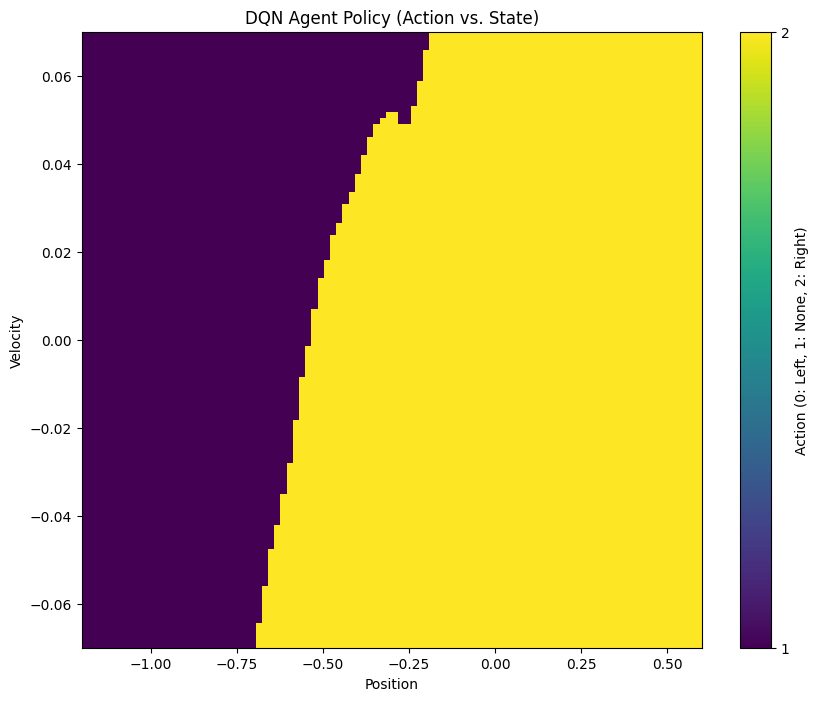

In [36]:
import matplotlib.pyplot as plt

# Define the observation space boundaries (position and velocity)
position_min, velocity_min = env.observation_space.low
position_max, velocity_max = env.observation_space.high

# Create a grid of observations
position_samples = np.linspace(position_min, position_max, 100)
velocity_samples = np.linspace(velocity_min, velocity_max, 100)

policy_grid = np.zeros((len(position_samples), len(velocity_samples)))

for i, pos in enumerate(position_samples):
    for j, vel in enumerate(velocity_samples):
        # Create a dummy observation to predict action
        obs = np.array([pos, vel], dtype=np.float32)
        action, _ = agent.predict(obs, deterministic=True)
        policy_grid[i, j] = action

# Plotting the policy
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(policy_grid.T, cmap='viridis', origin='lower',
               extent=[position_min, position_max, velocity_min, velocity_max],
               aspect='auto')

cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.set_label('Action (0: Left, 1: None, 2: Right)')

ax.set_xlabel('Position')
ax.set_ylabel('Velocity')
ax.set_title("DQN Agent Policy (Action vs. State)")
plt.show()

In [ ]:
random_env = mo_gym.make("mo-mountaincar-v0")

random_policy_grid = np.zeros((len(position_samples), len(velocity_samples)))

for i, pos in enumerate(position_samples):
    for j, vel in enumerate(velocity_samples):
        # Create a dummy observation
        obs = np.array([pos, vel], dtype=np.float32)
        # For a random agent, we just sample a random action from the action space
        action = random_env.action_space.sample()
        random_policy_grid[i, j] = action

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plotting the DQN agent's policy
im1 = axes[0].imshow(policy_grid.T, cmap='viridis', origin='lower',
                   extent=[position_min, position_max, velocity_min, velocity_max],
                   aspect='auto')
cbar1 = fig.colorbar(im1, ax=axes[0], ticks=[0, 1, 2])
cbar1.set_label('Action (0: Left, 1: None, 2: Right)')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Velocity')
axes[0].set_title("DQN Agent Policy")

# Plotting the Random agent's policy
im2 = axes[1].imshow(random_policy_grid.T, cmap='viridis', origin='lower',
                   extent=[position_min, position_max, velocity_min, velocity_max],
                   aspect='auto')
cbar2 = fig.colorbar(im2, ax=axes[1], ticks=[0, 1, 2])
cbar2.set_label('Action (0: Left, 1: None, 2: Right)')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Velocity')
axes[1].set_title("Random Agent Policy")

plt.tight_layout()
plt.show()